# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [18]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [20]:
# mostrar las primeras 5 filas de plans
print("PLANS")
print(plans.head())

PLANS
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [21]:
# mostrar las primeras 5 filas de users
print("USERS")
print(users.head())

USERS
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [22]:
# mostrar las primeras 5 filas de usage
print("USERS")
print(users.head())

USERS
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [17]:
plans.info()
users.info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   ci

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [23]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [24]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [25]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [26]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [28]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [29]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Se detectaron valores nulos en algunas columnas de los datasets users y usage.

Columnas con valores faltantes y proporción:
La mayoría de las columnas presentan una proporción baja de valores nulos (menor al 5%).

Acción recomendada:
Para columnas con menos del 5% de valores nulos, se recomienda imputar o mantenerlos, ya que no afectan significativamente el análisis.

En caso de columnas con mayor proporción de valores faltantes, se recomienda analizar el contexto antes de decidir imputación o eliminación.

En general, no se observa un problema crítico de missingness que comprometa el análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [30]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
La columna user_id funciona como identificador único, no presenta valores inválidos ni requiere limpieza.

- La columna `age` ...
La columna age presenta valores fuera de rango posible (ej. negativos o demasiado altos), lo que indica presencia de sentinels o errores de captura. Se recomienda limpiar o eliminar estos valores.

In [31]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...
Las columnas id y user_id funcionan como identificadores. Se debe verificar consistencia, pero no requieren tratamiento directo.

Las columnas duration y length presentan valores en cero, lo cual podría representar ausencia de uso o posibles registros incompletos. Se recomienda analizar si estos valores son válidos o requieren tratamiento.

In [32]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].unique())
    print()

city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan
['Basico' 'Premium']



- La columna `city` ...
La columna city contiene valores categóricos. Se detectan valores inválidos como '?' y valores nulos, lo que indica problemas de calidad de datos. Se recomienda limpiar o imputar estos valores y revisar consistencia en nombres.
- La columna `plan` ...
La columna plan muestra los tipos de suscripción. Se debe validar que coincidan con el dataset plans.

In [35]:
# explorar columna categórica de usage
print(usage['type'].unique())

['call' 'text']


- La columna `type` ...
La columna type contiene categorías de uso (llamadas o mensajes). Se recomienda verificar que no existan valores inesperados o inconsistentes.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Se identificaron valores inválidos o sentinels en las siguientes columnas:

- En la columna age se detecta el valor -999, el cual es un sentinel y no representa una edad válida.
- En la columna city se detecta el valor '?' y valores nulos, lo que indica datos faltantes o mal capturados.
- En las columnas duration y length se observan valores en cero, que podrían representar ausencia de uso o registros incompletos.

Acciones recomendadas:

- Para age: reemplazar el valor -999 por NaN y posteriormente imputar o eliminar según el contexto.
- Para city: reemplazar '?' por NaN y tratar los valores faltantes mediante imputación o análisis adicional.
- Para duration y length: analizar si los valores en cero son válidos (ej. no hubo uso) o si representan errores antes de decidir su tratamiento.

En general, se recomienda limpiar estos valores para evitar sesgos en el análisis posterior.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [40]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [41]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [42]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
En `date` solo se observa el año 2024, lo cual es consistente con el periodo de análisis. No se detectan años fuera de rango.

In [39]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

En `date` solo se observa el año 2024, lo cual es consistente con el periodo de análisis. No se detectan años fuera de rango.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

No se deben aceptar años posteriores a 2024, ya que el análisis está acotado a información registrada hasta ese año.

Si aparecen fechas fuera de rango, se recomienda:
- convertirlas a nulos con `errors='coerce'`,
- evaluar cuántos casos existen,
- y decidir entre eliminar esos registros o imputarlos solo si el contexto lo permite.

En general, las fechas inválidas deben tratarse antes de continuar el análisis, ya que podrían sesgar tendencias temporales y segmentaciones.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [43]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [44]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].unique())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [45]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [46]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificación MAR en usage para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [47]:
# Verificación MAR en usage (Missing At Random) para length
# Verificación MAR en usage para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se observa que los valores nulos en las columnas `duration` y `length` dependen del tipo de registro (`type`).

Para los registros de tipo 'call', es normal que la columna `length` esté vacía, ya que no aplica a llamadas.
Para los registros de tipo 'text', es normal que la columna `duration` esté vacía, ya que no aplica a mensajes.

Esto indica que los valores faltantes son de tipo MAR (Missing At Random), ya que dependen de otra variable del dataset y no de errores de captura.

Por lo tanto, se recomienda mantener estos valores como nulos, ya que representan correctamente el comportamiento del negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [48]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)   # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [49]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [50]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [51]:
# Resumen estadístico de las columnas numéricas
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [52]:
# Distribución porcentual del tipo de plan
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

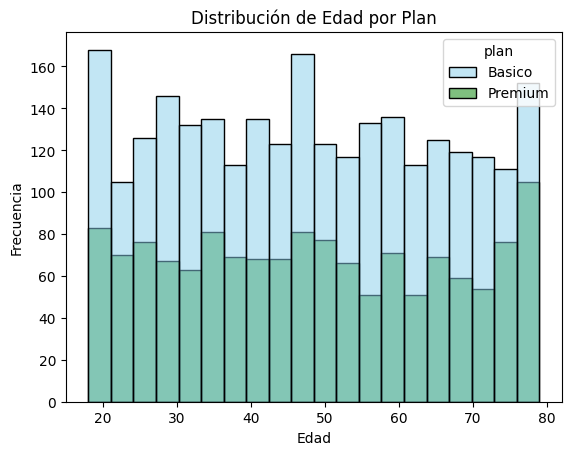

In [53]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=20)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...
La distribución de edad es aproximadamente simétrica, con mayor concentración entre los 30 y 60 años. No se observan diferencias significativas entre los planes Básico y Premium en términos de edad.

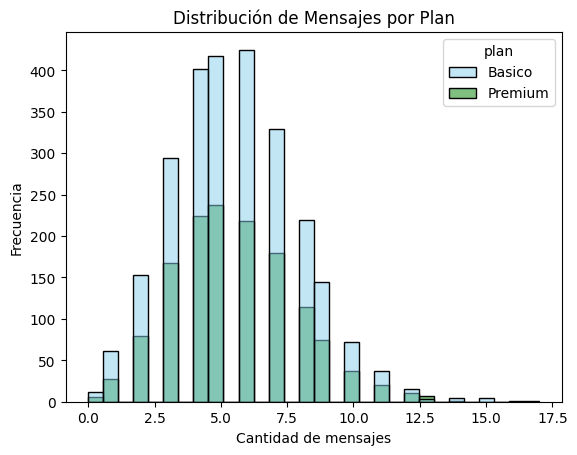

In [55]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ....

La distribución está sesgada a la derecha, indicando que la mayoría de los usuarios envía pocos mensajes, mientras que pocos usuarios envían grandes cantidades. Los usuarios Premium tienden a enviar más mensajes en comparación con el plan Básico.

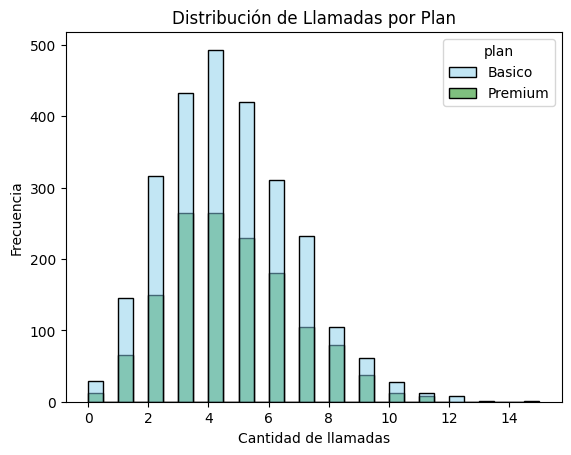

In [56]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

La distribución presenta sesgo a la derecha. La mayoría de los usuarios realiza pocas llamadas, mientras que algunos usuarios presentan un alto volumen. No se observa una diferencia marcada entre los planes.

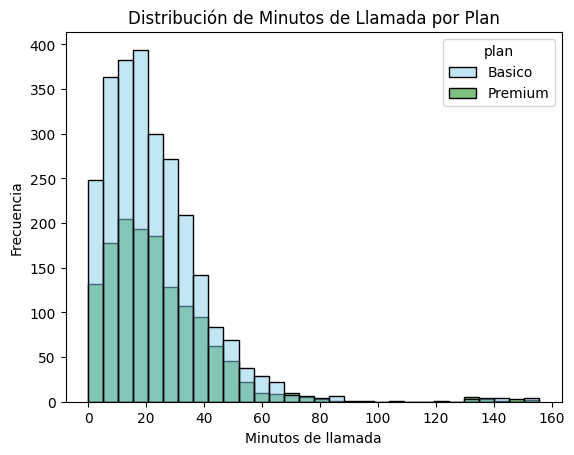

In [57]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=30)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ...
La distribución está fuertemente sesgada a la derecha, con la mayoría de los usuarios concentrados en valores bajos y algunos casos extremos con alto consumo. Los usuarios Premium muestran mayor consumo de minutos en comparación con el plan Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

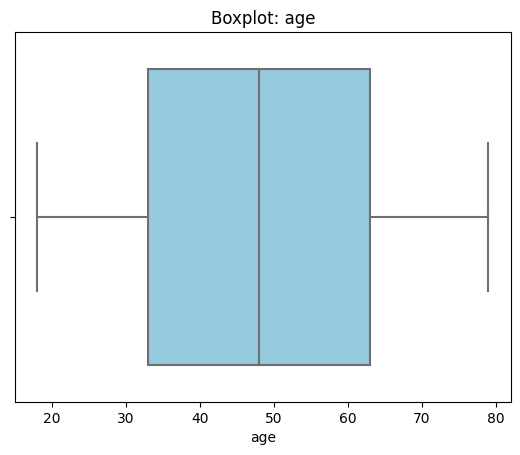

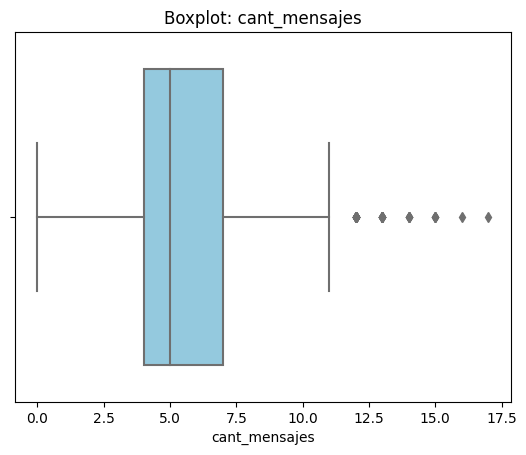

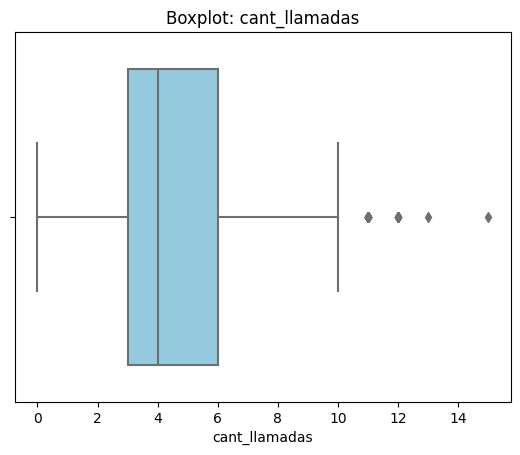

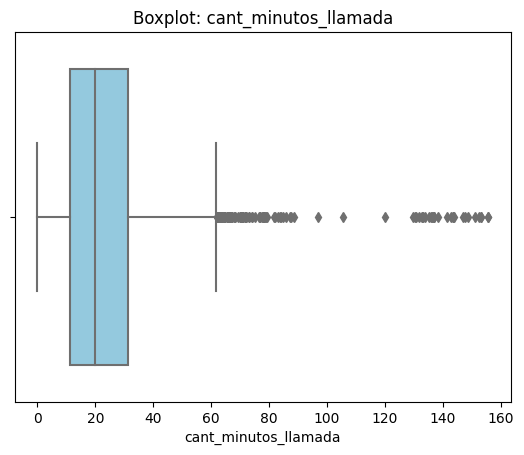

In [58]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

Age: No presenta outliers significativos, la distribución es relativamente estable.

cant_mensajes: Presenta outliers hacia valores altos, indicando usuarios con uso intensivo de mensajes.

cant_llamadas: Presenta algunos outliers en la parte superior, reflejando usuarios con alto volumen de llamadas.

cant_minutos_llamada: Presenta outliers claros hacia valores altos, indicando usuarios con consumo elevado de minutos.

In [59]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']



In [60]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

cant_mensajes: Se recomienda mantener los outliers, ya que representan usuarios con alto volumen de mensajes. Este comportamiento es válido dentro del negocio y puede ser útil para identificar clientes intensivos.

cant_llamadas: Se recomienda mantener los outliers, ya que reflejan usuarios con un alto número de llamadas. No se consideran errores, sino patrones reales de uso.

cant_minutos_llamada: Se recomienda mantener los outliers, ya que corresponden a usuarios con alto consumo de minutos. Estos valores son importantes para el análisis de clientes de alto valor o heavy users.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [61]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
    'grupo_uso'
] = 'Uso medio'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

In [62]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [64]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 60,
    'grupo_edad'
] = 'Adulto'

user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

In [65]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

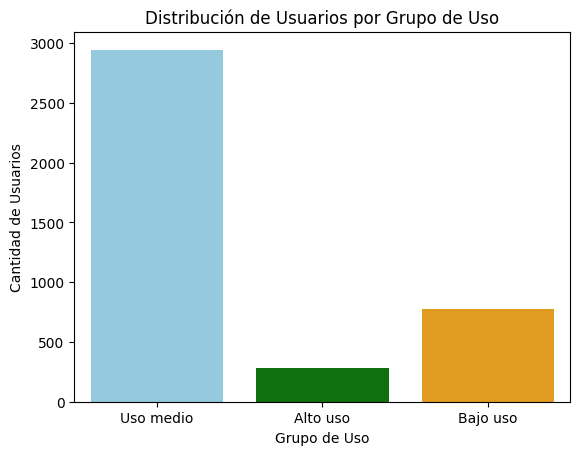

In [66]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green','orange'])

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

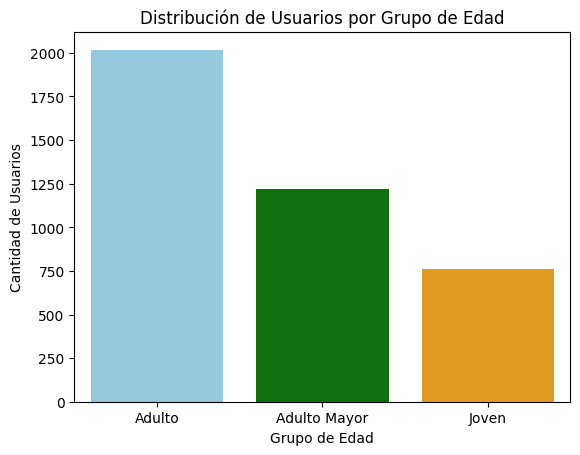

In [67]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green','orange'])

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Durante el análisis de los datos de ConnectaTel se identificaron diversos problemas de calidad que debieron ser corregidos antes del análisis.

En el dataset de usuarios, la columna age presentaba valores inválidos como -999, los cuales corresponden a sentinels y no representan edades reales. Además, en la columna city se detectaron valores como '?' y valores nulos, indicando errores de captura o datos faltantes. En las fechas de registro (reg_date) se identificaron registros en el año 2026, fuera del rango esperado del análisis (hasta 2024), lo que representa aproximadamente 40 registros y corresponde a errores de captura.

En el dataset de uso, se identificaron valores nulos en las columnas duration y length. Sin embargo, estos valores se clasificaron como MAR (Missing At Random), ya que dependen del tipo de registro (call o text), por lo que no representan errores y se mantuvieron.

En cuanto a la segmentación, se clasificaron los usuarios según su nivel de uso en Bajo uso, Uso medio y Alto uso, y por edad en Jóvenes, Adultos y Adultos Mayores. Se observó que la mayoría de los usuarios se concentra en niveles de uso bajo y medio, mientras que un grupo menor presenta alto uso, representando clientes intensivos.

Los segmentos más valiosos para ConnectaTel son los usuarios de Alto uso, ya que concentran mayor consumo de llamadas y mensajes, lo que implica mayor generación de ingresos. Estos usuarios pueden ser considerados como clientes de alto valor o potenciales candidatos para planes premium.

Respecto a los outliers, se identificaron valores extremos principalmente en las variables de uso (mensajes, llamadas y minutos). Estos no representan errores, sino usuarios con comportamiento intensivo, lo cual es común en servicios de telecomunicaciones. Estos casos son relevantes para el negocio, ya que pueden indicar oportunidades de segmentación avanzada o personalización de servicios.

Finalmente, se recomienda a ConnectaTel considerar la creación o ajuste de planes diferenciados según el comportamiento de uso. Por ejemplo, planes con beneficios adicionales para usuarios intensivos (más minutos o mensajes incluidos) y planes básicos optimizados para usuarios de bajo consumo. Asimismo, se sugiere implementar estrategias de retención y fidelización para los clientes de alto valor, así como mejorar los procesos de captura de datos para evitar errores en futuras bases de datos.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc
Se identificaron valores inválidos en la columna age (valor -999), lo que indica presencia de sentinels que no representan datos reales.  
En la columna city se detectaron valores como '?' y valores nulos, reflejando errores de captura o datos faltantes.  
Además, en la columna reg_date se encontraron registros en el año 2026 (40 casos), fuera del rango esperado del análisis (hasta 2024), lo que indica errores de registro.  
En el dataset de uso, los valores nulos en duration y length se clasificaron como MAR, ya que dependen del tipo de evento (call o text), por lo que no representan errores.

🔍 **Segmentos por Edad**
- abc
- abc 

Los usuarios se agrupan principalmente en el segmento Adulto (30–59 años), seguido por Adultos Mayores y un menor porcentaje de Jóvenes.  
No se observan diferencias significativas en la distribución de edad entre los planes, lo que sugiere que la edad no es un factor determinante en la elección del plan.

📊 **Segmentos por Nivel de Uso**
- abc
- abc
La mayoría de los usuarios se concentra en Bajo uso y Uso medio, mientras que un grupo menor presenta Alto uso.  
Los usuarios de alto uso muestran un comportamiento intensivo en llamadas y mensajes, lo que indica un mayor consumo del servicio.

➡️ Esto sugiere que ...
Esto sugiere que existe una base amplia de usuarios con bajo consumo y un segmento reducido pero altamente valioso con consumo elevado.

💡 **Recomendaciones**
- abc
- abc
Se recomienda desarrollar planes diferenciados según el nivel de uso, creando ofertas específicas para usuarios intensivos que incluyan beneficios adicionales en llamadas y mensajes.  
Para usuarios de bajo consumo, se sugiere optimizar planes básicos con precios más accesibles para mejorar la retención.  
Asimismo, es importante implementar controles en la captura de datos para evitar errores como fechas fuera de rango o valores inválidos.  
Finalmente, se recomienda enfocar estrategias de fidelización en los usuarios de alto consumo, ya que representan mayor valor para el negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`